# Definition of classes

In [1]:
import torch
from typing import Union, Tuple
from mlcolvar.core.loss.utils.smart_derivatives import SmartDerivatives
from mlcolvar.utils._code import scatter_sum


/home/tdevergne@iit.local/anaconda3/envs/kooplearn-reborn/lib/python3.9/site-packages/lightning_utilities/core/imports.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import torch
import lightning
from typing import Union, Tuple,List
from mlcolvar.cvs import BaseCV
from mlcolvar.core import FeedForward, BaseGNN
from mlcolvar.core.loss.generator_loss import GeneratorLoss
from mlcolvar.cvs.generator.utils import compute_eigenfunctions
from mlcolvar.core.loss.utils.smart_derivatives import SmartDerivatives
from mlcolvar.data import DictDataset


# Run code

### Load data
Here I am using mdtraj, as there is no bias, everything is centered and there is no bias potential

In [3]:
torch.manual_seed(42)

from mlcolvar.data import DictModule
import mdtraj as md
import numpy as np
from mlcolvar.data import DictModule
from mlcolvar.utils.io import create_dataset_from_files
from mlcolvar.cvs.committor.utils import compute_committor_weights

################################### SET THINGS HERE ###################################
filenames = [ f"../data/COLVAR_chignolin"]

load_args = [{'start' : 0, 'stop': None, 'stride': 5},
            ]                     

########################################################################################

dataset, dataframe = create_dataset_from_files(file_names=filenames,
                                               create_labels=True,
                                               filter_args={'regex': 'p*.x|p*.y|p*.z'}, # to load many positions --> 'regex': 'p[1-9]\.[abc]|p[1-2][0-9]\.[abc]'
                                               return_dataframe=True,
                                               load_args=load_args,
                                               verbose=True)

bias = torch.ones(dataset["data"].shape[0])
dataset = compute_committor_weights(dataset, bias, [0], beta=1) # it's muller

# create datamodule with only training set
datamodule = DictModule(dataset, lengths=[0.8,0.2],random_split=True,shuffle=True)


/home/tdevergne@iit.local/anaconda3/envs/kooplearn-reborn/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Class 0 dataframe shape:  (19290, 33)

 - Loaded dataframe (19290, 33): ['time', 'p0.x', 'p0.y', 'p0.z', 'p1.x', 'p1.y', 'p1.z', 'p2.x', 'p2.y', 'p2.z', 'p3.x', 'p3.y', 'p3.z', 'p4.x', 'p4.y', 'p4.z', 'p5.x', 'p5.y', 'p5.z', 'p6.x', 'p6.y', 'p6.z', 'p7.x', 'p7.y', 'p7.z', 'p8.x', 'p8.y', 'p8.z', 'p9.x', 'p9.y', 'p9.z', 'walker', 'labels']
 - Descriptors (19290, 30): ['p0.x', 'p0.y', 'p0.z', 'p1.x', 'p1.y', 'p1.z', 'p2.x', 'p2.y', 'p2.z', 'p3.x', 'p3.y', 'p3.z', 'p4.x', 'p4.y', 'p4.z', 'p5.x', 'p5.y', 'p5.z', 'p6.x', 'p6.y', 'p6.z', 'p7.x', 'p7.y', 'p7.z', 'p8.x', 'p8.y', 'p8.z', 'p9.x', 'p9.y', 'p9.z']


In [4]:
import mdtraj as md

traj = md.load("/home/tdevergne@iit.local/Documents/bioemu/bioemu/chignolin/samples.xtc", top="/home/tdevergne@iit.local/Documents/bioemu/bioemu/chignolin/topology.pdb")
ca_indices = traj.topology.select('name CA')

pos_traj = torch.Tensor(traj.xyz[:,ca_indices,:])

### Compute descriptors
Here the data comes from bioemu, so there is no PBC, no cell

In [5]:
from mlcolvar.core.transform import PairwiseDistances
from mlcolvar.core.loss.utils.smart_derivatives import SmartDerivatives, compute_descriptors_derivatives
from mlcolvar.cvs.committor.utils import compute_committor_weights
n_atoms = 10
ComputeDistances = PairwiseDistances(n_atoms=n_atoms, PBC=False, cell=False, scaled_coords=False)


In [6]:
from mlcolvar.data import DictModule, DictDataset



smart_derivatives = SmartDerivatives( force_all_atoms=True)

smart_dataset = smart_derivatives.setup(dataset, ComputeDistances, n_atoms, descriptors_batch_size=500)


Processed all data in 39 batches!


### Create de datamodule
Chignolin is very simple, if you have a bigger system, it might be necessary to use minibatches by specifying the argument batch_size=... (start with quite large 20000-10000)

In [7]:

# load dataset into a DictModule
datamodule = DictModule(dataset=smart_dataset)
print('Datamodule info:\n', datamodule)

Datamodule info:
 DictModule(dataset -> DictDataset( "data": [19290, 45], "labels": [19290], "weights": [19290], "ref_idx": [19290], metadata={ "data_type": descriptors } ),
		     train_loader -> DictLoader(length=0.8, batch_size=0, shuffle=True),
		     valid_loader -> DictLoader(length=0.2, batch_size=0, shuffle=True))


This is just a prefactor containing the mass and the temperature, I am only using C alpha, so only C masses

In [8]:
import numpy as np
masses = [12.011]*10
n_atoms = 10#10
gamma = 1#1/0.05

friction = 300*0.0083144621/torch.tensor(masses).to(torch.float32)

In [9]:
options = {'optimizer' : {'lr' : 1e-3,'weight_decay': 1E-6},
           'lr_scheduler': {
            'scheduler': torch.optim.lr_scheduler.ExponentialLR,
            'gamma': 0.99992},
        }

Here set the parameters for the generator model, in this new version, a large $\eta$ seems to work, if you want to check you can decrease it. Regarding the value of $r$, usually I start with 6. Normally, you should see the ortho part of the loss decrease towards one by plateaus during the training.

In [10]:
from mlcolvar.cvs.generator import Generator


model =  Generator(model=[45,32,32,3],eta=50.0,r=3,alpha=1.0,friction=friction, descriptors_derivatives=smart_derivatives)
model.optimizer_name="AdamW"

/home/tdevergne@iit.local/anaconda3/envs/kooplearn-reborn/lib/python3.9/site-packages/lightning/pytorch/utilities/parsing.py:199: Attribute 'descriptors_derivatives' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['descriptors_derivatives'])`.


In [11]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("CUDA version:", torch.version.cuda)


CUDA available: True
CUDA device count: 2
CUDA version: 11.8


Some imports here might be useless for you here, like wandb. It is very useful to track the state of the training and see the loss even after training. I am using a custom callback for the checkpoints, so that it only saves the important information. Otherwise, it saves the smart_derivatives which is very heavy on disk

In [12]:
import lightning
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from mlcolvar.utils.trainer import MetricsCallback
from lightning.pytorch.callbacks import ModelCheckpoint

from lightning.pytorch.loggers import WandbLogger

import wandb
from lightning.pytorch.loggers import WandbLogger 
wandb_logger = WandbLogger(name="r6_500",project='chignolin_bioemu_distances') #The logger is not mandatory
metrics = MetricsCallback()
class StateDictCheckpoint(ModelCheckpoint):
    def _save_checkpoint(self, trainer, filepath):
        state_dict = trainer.lightning_module.state_dict()
        torch.save(state_dict, filepath)
#ckpt_callback=StateDictCheckpoint(dirpath='/work/tdevergne/bioemu_fun/chignolin/distances/r6_eta500_gnn_alpha1',every_n_epochs=1,save_last=False,save_top_k=5,save_weights_only=True,monitor="valid_loss")
# initialize trainer, for testing the number of epochs is low, change this 5o something like 4/5000
trainer = lightning.Trainer(callbacks=[metrics],#,early_stop_callback], 
                            max_epochs=20000, 
                            enable_checkpointing=True,
                            enable_progress_bar=False,
                            logger=wandb_logger,
                            enable_model_summary=False,
                            gradient_clip_val=1.0,            # clip global grad norm to 1.0
                            gradient_clip_algorithm="norm",
                            accelerator="gpu"
                              # this to skip validation
                            )
# fit model
trainer.fit(model, datamodule)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: timothee-devergne (tdevergne). Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


[SmartDerivatives] Moving left to cuda:0
[SmartDerivatives] Moving batch_ind to cuda:0
[SmartDerivatives] Moving desc_ind to cuda:0
[SmartDerivatives] Moving scatter_indeces to cuda:0
[SmartDerivatives] Moving batch_shift to cuda:0
[SmartDerivatives] To move the preloaded tensors back to cpu, use the `SmartDerivatives.move_to_cpu` method


/home/tdevergne@iit.local/anaconda3/envs/kooplearn-reborn/lib/python3.9/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=20000` reached.


In [16]:
smart_dataset["data"] = smart_dataset["data"].cpu()
smart_dataset["weights"] = smart_dataset["weights"].cpu()
smart_derivatives.move_to_cpu()
eigenfunctions,evals, evecs = model.cpu().compute_eigenfunctions(smart_dataset,friction=friction.cpu(),eta=500, batch_size=500,tikhonov_reg=1e-6,descriptors_derivatives=smart_derivatives)

[SmartDerivatives] Moving left to cpu
[SmartDerivatives] Moving batch_ind to cpu
[SmartDerivatives] Moving desc_ind to cpu
[SmartDerivatives] Moving scatter_indeces to cpu
[SmartDerivatives] Moving batch_shift to cpu
[SmartDerivatives] To move the preloaded tensors back to cpu, use the `SmartDerivatives.move_to_cpu` method


In [17]:
evals

tensor([ 8.9407e-04, -2.2334e-01, -9.6685e-01])

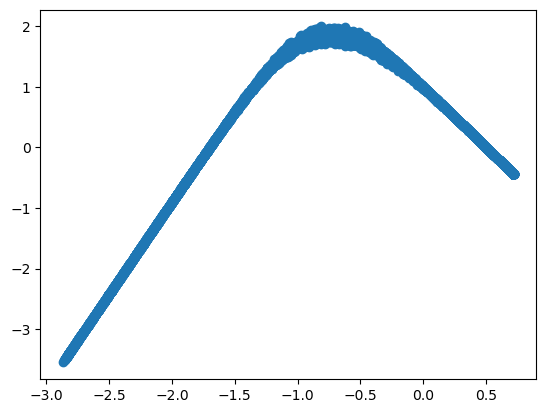

In [19]:
import matplotlib.pyplot as plt
plt.scatter(eigenfunctions[:,1].detach(),eigenfunctions[:,2].detach())